# ML-07 — Baseline Action Score and Top-20 Review

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Maryam-Shile/flyrank_ml_internship/blob/main/work/notebooks/w04_baseline_score.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. My rule and its reason codes

*Write the rule in plain words first. Then the reason codes it can output.*

In [35]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
url = 'https://raw.githubusercontent.com/Maryam-Shile/flyrank_ml_internship/refs/heads/main/data/raw/content_refresh_anonymized.csv'
df = pd.read_csv(url)
df.head()

,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,...,NaN,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7


In [4]:
df.groupby('competition_level')[['search_volume', 'competition']].agg(
    ['median', 'mean']
)

search_volume             competition          
                         median        mean      median      mean
competition_level                                                
HIGH                       20.0  291.629044        0.98  0.915854
LOW                        10.0  131.930468        0.00  0.031809
MEDIUM                     20.0  315.098039        0.48  0.481111

In [5]:
print(df[['engagement_rate', 'scroll_rate']].describe())
print(df[['scroll_rate', 'scroll_events_90d']].corr())

       engagement_rate   scroll_rate
count     30000.000000  29875.000000
mean          2.534520     18.212921
std           8.310096     29.472768
min           0.000000      0.000000
25%           0.000000      0.000000
50%           0.000000      5.000000
75%           1.350000     23.530000
max         100.000000    300.000000
                   scroll_rate  scroll_events_90d
scroll_rate           1.000000           0.027079
scroll_events_90d     0.027079           1.000000


In [6]:
impression_columns = []
for i in df.columns:
  if 'impression' in i:
    if 'tier' not in i:
      impression_columns.append(i)
  elif 'click' in i:
    impression_columns.append(i)




impression_columns

['impressions_90d',
 'clicks_90d',
 'days_with_impressions',
 'impressions_last_30d',
 'clicks_last_30d',
 'impressions_prev_30d',
 'clicks_prev_30d']

In [7]:
df.groupby('impression_tier')[impression_columns].median()

,impressions_90d,clicks_90d,days_with_impressions,impressions_last_30d,clicks_last_30d,impressions_prev_30d,clicks_prev_30d
impression_tier,,,,,,,
excellent,48675.0,116.0,88.0,14329.0,34.0,17327.0,38.0
good,7249.0,16.0,88.0,1702.0,4.0,2349.0,4.0
low,31.0,0.0,17.0,3.0,0.0,7.0,0.0
moderate,998.0,1.0,86.0,198.0,0.0,296.0,0.0


In [8]:
df['ctr_tier'] = pd.qcut(df['ctr'], q = 3, duplicates = 'drop')

df.groupby('ctr_tier')[impression_columns].median()

/tmp/ipykernel_2309/3743928593.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('ctr_tier')[impression_columns].median()


,impressions_90d,clicks_90d,days_with_impressions,impressions_last_30d,clicks_last_30d,impressions_prev_30d,clicks_prev_30d
ctr_tier,,,,,,,
"(-0.001, 0.2]",399.0,0.0,71.0,65.0,0.0,110.0,0.0
"(0.2, 100.0]",2189.0,9.0,88.0,477.0,2.0,683.0,3.0


<Axes: >

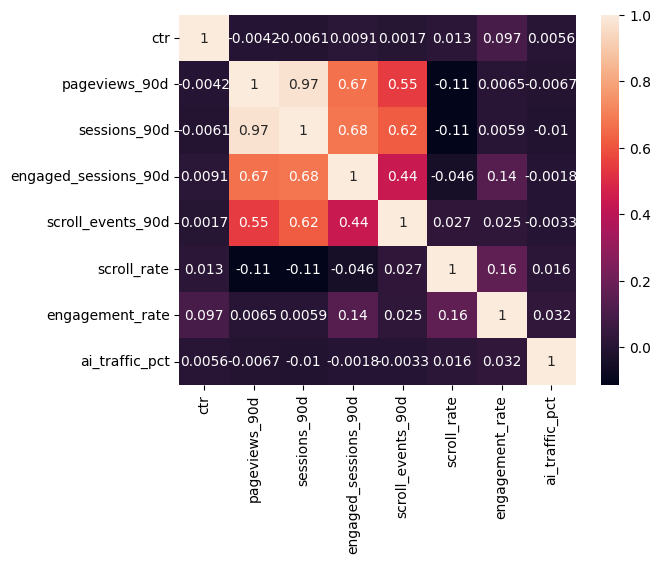

In [9]:


to_corr = df[['ctr', 'pageviews_90d', 'sessions_90d', 'engaged_sessions_90d', 'scroll_events_90d', 'scroll_rate', 'engagement_rate', 'ai_traffic_pct']]
sns.heatmap(to_corr.corr(), annot = True)

In [10]:
tiered = ['age_tier', 'freshness_tier', 'impression_tier', 'position_tier']

for i in tiered:
  print(i)
  print(df[i].nunique())

age_tier
4
freshness_tier
4
impression_tier
4
position_tier
5


In [26]:
df_new = df[['ctr_tier', 'search_volume', 'char_count', 'provider_used', 'model_used', 'competition_level',
'age_tier_order', 'freshness_tier', 'position_tier', 'trend_direction', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct']].copy()
df_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   ctr_tier           30000 non-null  category
 1   search_volume      27532 non-null  float64 
 2   char_count         22301 non-null  float64 
 3   provider_used      8562 non-null   object  
 4   model_used         24267 non-null  object  
 5   competition_level  27390 non-null  object  
 6   age_tier_order     30000 non-null  int64   
 7   freshness_tier     30000 non-null  object  
 8   position_tier      30000 non-null  object  
 9   trend_direction    30000 non-null  object  
 10  engagement_rate    30000 non-null  float64 
 11  scroll_rate        29875 non-null  float64 
 12  ai_traffic_pct     30000 non-null  float64 
dtypes: category(1), float64(5), int64(1), object(6)
memory usage: 2.8+ MB


In [27]:
df_new.head()

,ctr_tier,search_volume,char_count,provider_used,model_used,competition_level,age_tier_order,freshness_tier,position_tier,trend_direction,engagement_rate,scroll_rate,ai_traffic_pct
0,"(0.2, 100.0]",10.0,20457.0,NaN,gemini-2.5-flash,HIGH,5,0-30,striking,down,5.88,4.55,0.0
1,"(-0.001, 0.2]",90.0,15562.0,NaN,gemini-3-flash-preview,LOW,6,0-30,page_3_5,down,0.00,10.00,0.0
2,"(-0.001, 0.2]",0.0,23643.0,NaN,gemini-2.5-flash,LOW,4,0-30,page_3_5,down,0.00,28.57,0.0
3,"(0.2, 100.0]",10.0,NaN,NaN,NaN,LOW,6,0-30,page_1,stable,1.28,3.45,0.0
4,"(-0.001, 0.2]",0.0,17469.0,NaN,gemini-3-flash-preview,LOW,5,0-30,page_3_5,down,0.00,24.29,0.0


In [28]:
df_new['ctr_tier'] = df_new['ctr_tier'].astype('str')

In [21]:
for i in df_new.columns:
  print(i)
  print(df_new[i].value_counts())

ctr_tier
ctr_tier
(-0.001, 0.2]    20305
(0.2, 100.0]      9695
Name: count, dtype: int64
search_volume
search_volume
0.0        11081
10.0        7311
20.0        2290
30.0        1224
40.0         753
50.0         722
70.0         640
90.0         462
110.0        359
140.0        344
170.0        276
210.0        249
260.0        232
320.0        194
480.0        186
390.0        181
590.0        151
720.0        114
1000.0       104
880.0         99
1600.0        78
1300.0        74
2900.0        62
2400.0        57
1900.0        55
3600.0        48
4400.0        34
5400.0        27
6600.0        26
14800.0       23
8100.0        18
9900.0        14
22200.0        9
12100.0        7
18100.0        7
33100.0        4
27100.0        4
40500.0        4
60500.0        4
49500.0        4
74000.0        1
Name: count, dtype: int64
char_count
char_count
18826.0    8
16833.0    7
20141.0    7
17917.0    7
16540.0    7
          ..
30449.0    1
10359.0    1
21431.0    1
20966.0    1
42548.0

In [29]:
ctr_map = {'(-0.001, 0.2]': 1, '(0.2, 100.0]': 2}
competition_map = {'HIGH': 1.5, 'MEDIUM': 1, 'LOW': 0.8}
trend_map = {'down': -1, 'flat': 2, 'stable': 3, 'up': 4, 'new': 5}
position_map = {'deep': 1, 'page_3_5': 2, 'striking': 3, 'page_1': 4, 'top_3': 5}
age_scale_map = {1: 1.0, 2: 1.0, 3: 0.95, 4: 0.90, 5: 0.80, 6: 0.70}




df_new['ctr_tier_order'] = df_new['ctr_tier'].map(ctr_map)
df_new['competition_order'] = df_new['competition_level'].map(competition_map)
df_new['trend_order'] = df_new['trend_direction'].map(trend_map)
df_new['position_order'] = df_new['position_tier'].map(position_map)
df_new["raw_age_modifier"] = df_new["age_tier_order"].map(age_scale_map)



df_new.drop(columns = ['ctr_tier', 'competition_level', 'trend_direction', 'position_tier'], axis = 1, inplace = True)
df_new.head()


,search_volume,char_count,provider_used,model_used,age_tier_order,freshness_tier,engagement_rate,scroll_rate,ai_traffic_pct,ctr_tier_order,competition_order,trend_order,position_order
0,10.0,20457.0,NaN,gemini-2.5-flash,5,0-30,5.88,4.55,0.0,2,1.5,-1,3
1,90.0,15562.0,NaN,gemini-3-flash-preview,6,0-30,0.00,10.00,0.0,1,0.8,-1,2
2,0.0,23643.0,NaN,gemini-2.5-flash,4,0-30,0.00,28.57,0.0,1,0.8,-1,2
3,10.0,NaN,NaN,NaN,6,0-30,1.28,3.45,0.0,2,0.8,3,4
4,0.0,17469.0,NaN,gemini-3-flash-preview,5,0-30,0.00,24.29,0.0,1,0.8,-1,2


In [30]:
df_new.describe()

,search_volume,char_count,age_tier_order,engagement_rate,scroll_rate,ai_traffic_pct,ctr_tier_order,competition_order,trend_order,position_order
count,27532.000000,22301.000000,30000.000000,30000.000000,29875.000000,30000.000000,30000.000000,27390.000000,30000.000000,30000.000000
mean,158.882391,20665.277835,4.786533,2.534520,18.212921,0.768196,1.323167,0.881336,1.088667,3.219200
std,1518.270825,10115.344042,0.790392,8.310096,29.472768,7.429454,0.467694,0.208850,2.345816,1.035626
min,0.000000,40.000000,3.000000,0.000000,0.000000,0.000000,1.000000,0.800000,-1.000000,1.000000
25%,0.000000,15644.000000,4.000000,0.000000,0.000000,0.000000,1.000000,0.800000,-1.000000,2.000000
50%,10.000000,19116.000000,5.000000,0.000000,5.000000,0.000000,1.000000,0.800000,-1.000000,3.000000
75%,20.000000,24011.000000,5.000000,1.350000,23.530000,0.000000,2.000000,0.800000,3.000000,4.000000
max,74000.000000,111158.000000,6.000000,100.000000,300.000000,300.000000,2.000000,1.500000,5.000000,5.000000


In [31]:
df_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   search_volume      27532 non-null  float64
 1   char_count         22301 non-null  float64
 2   provider_used      8562 non-null   object 
 3   model_used         24267 non-null  object 
 4   age_tier_order     30000 non-null  int64  
 5   freshness_tier     30000 non-null  object 
 6   engagement_rate    30000 non-null  float64
 7   scroll_rate        29875 non-null  float64
 8   ai_traffic_pct     30000 non-null  float64
 9   ctr_tier_order     30000 non-null  int64  
 10  competition_order  27390 non-null  float64
 11  trend_order        30000 non-null  int64  
 12  position_order     30000 non-null  int64  
dtypes: float64(6), int64(4), object(3)
memory usage: 3.0+ MB


In [33]:
# Fill missing environment/content values with medians where applicable
df_new["search_volume"] = df_new["search_volume"].fillna(0)
df_new["competition_order"] = df_new["competition_order"].fillna(0.8)
df_new["char_count"] = df_new["char_count"].fillna(df_new["char_count"].median())
df_new["scroll_rate"] = df_new["scroll_rate"].fillna(0)

df_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   search_volume      30000 non-null  float64
 1   char_count         30000 non-null  float64
 2   provider_used      8562 non-null   object 
 3   model_used         24267 non-null  object 
 4   age_tier_order     30000 non-null  int64  
 5   freshness_tier     30000 non-null  object 
 6   engagement_rate    30000 non-null  float64
 7   scroll_rate        30000 non-null  float64
 8   ai_traffic_pct     30000 non-null  float64
 9   ctr_tier_order     30000 non-null  int64  
 10  competition_order  30000 non-null  float64
 11  trend_order        30000 non-null  int64  
 12  position_order     30000 non-null  int64  
dtypes: float64(6), int64(4), object(3)
memory usage: 3.0+ MB


In [36]:
# 1. Normalize Core Success Metrics (0 to 1 scale)
df_new["norm_trend"] = (df_new["trend_order"] + 1) / 6
df_new["norm_pos"] = (df_new["position_order"] - 1) / 4
df_new["norm_ctr"] = df_new["ctr_tier_order"] - 1

# Handle heavily skewed continuous success metrics using 95th percentile caps
df_new['engagement_order'] = df_new['engagement_rate'].rank(pct = True)

## 2. Build the ranked queue (writes the CSV)

*Code the score, rank everything, write work/outputs/baseline_action_score.csv.*

In [13]:
# 2. Compute Weighted Baseline Performance Score (BPS)
df_new["bps"] = (
    (df_new["norm_trend"] * 0.4)
    + (df_new["norm_pos"] * 0.3)
    + (df_new["norm_ctr"] * 0.15)
    + (df_new["norm_eng"] * 0.15)
)

# 3. Environment Multipliers
df_new["vol_multiplier"] = 1 + np.log10(df_new["search_volume"] + 1)

# 4. Conditional Content Penalties (Triggered only if baseline performance is low)
# If BPS is low (< 0.4) AND content age tier is old (e.g., tier 6), apply 0.75 penalty
df_new["age_penalty"] = np.where(
    df_new["bps"] < 0.4,              # CONDITION: Is the performance struggling?
    df_new["raw_age_modifier"],       # IF TRUE: Apply its specific sliding scale penalty (1 to 6)
    1.0                               # IF FALSE: Keep it perfectly safe at 1.0
)

# 5. Final Composite Action Score
# Low Score = Critical Action Needed | High Score = All Is Well
df["composite_action_score"] = (
    (df["bps"] / df["competition_order"]) * df["vol_multiplier"]
) * df["age_penalty"]

# Sort dataset so the highest emergencies pop up at the top
df = df.sort_values(by="composite_action_score", ascending=True)



,count
main_intent_x_content_type,
informational_keyword article,16538
transactional_keyword article,5733
commercial_keyword article,4612
informational_comparison article,697
navigational_keyword article,46


In [14]:
df.drop(columns = ['main_intent', 'content_type'], axis = 1, inplace = True)


info_key = df[df['main_intent_x_content_type'] == 'informational_keyword article'].copy()
trans_key = df[df['main_intent_x_content_type'] == 'transactional_keyword article'].copy()
com_key = df[df['main_intent_x_content_type'] == 'commercial_keyword article'].copy()
info_comp = df[df['main_intent_x_content_type'] == 'informational_comparison article'].copy()
nav_key = df[df['main_intent_x_content_type'] == 'navigational_keyword article'].copy()

all_group = [info_key, trans_key, com_key, info_comp, nav_key]


## 3. Top-20 review

*For each of the top 20: action, reason code, confidence note, and what would make it wrong.*

In [15]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 4. Weak picks + leakage check

*Which picks look wrong and why? Confirm no product flags or future windows leaked in.*

In [16]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.